# Step 2: Precision Calculation

## 2.1 Initialize the Environment and Load Data

*   Load the cleaned system runs and qrels
*   Print both datasets to ensure the data is loaded correctly





In [ ]:
# import the Pandas library for handling and analyzing data
import pandas as pd

# Load the cleaned system runs ('clean_system_runs_FINAL.csv' file)
# store it in dataframe df_runs
df_runs = pd.read_csv('clean_system_runs_FINAL.csv')

# Qrels format is usually: TopicID Iteration DocID Relevance
# create a list of column names
# These names describe what each column in the Qrels file represents
qrels_cols = ['topic_id', 'iteration', 'doc_id', 'relevance']
# Load the Qrels file (qrels.trec8.adhoc' file)
# sep='\s+' : the file is not comma-separated, it is separated by spaces/tabs
# names=qrels_cols : assigns the column names
df_qrels = pd.read_csv('qrels.trec8.adhoc', sep=r'\s+', names=qrels_cols)

# Preview the data to ensure the data is loaded correctly
print("System Runs:")
print(df_runs.head(15))
print("\nQrels:")
print(df_qrels.head(15))

System Runs:
    Topic_ID Iteration       Doc_ID  Rank     Score System_Name
0        401        Q0  FT932-10861     1  0.466239   CL99XTopt
1        401        Q0  FBIS3-30642     2  0.432951   CL99XTopt
2        401        Q0  FBIS3-40017     3  0.429149   CL99XTopt
3        401        Q0  FBIS4-18182     4  0.425154   CL99XTopt
4        401        Q0  FT934-15047     5  0.424532   CL99XTopt
5        401        Q0   FBIS3-5584     6  0.423666   CL99XTopt
6        401        Q0  FBIS3-38677     7  0.423611   CL99XTopt
7        401        Q0  FBIS4-23811     8  0.423541   CL99XTopt
8        401        Q0  FT931-16878     9  0.423072   CL99XTopt
9        401        Q0   FT924-7265    10  0.422821   CL99XTopt
10       401        Q0  FT932-13416    11  0.422771   CL99XTopt
11       401        Q0  FBIS3-18684    12  0.422190   CL99XTopt
12       401        Q0   FBIS3-8571    13  0.422140   CL99XTopt
13       401        Q0  FBIS4-64863    14  0.421991   CL99XTopt
14       401        Q0  FBI

## 2.2 Define the Precision@k Function


*   Take top K retrieved documents
*   Get all relevant documents
*   Find the intersection (overlap)
*   Divide by K





In [ ]:
# Define a function named calculate_precision_at_k
# the function takes 3 inputs
# system_results : the retrieved documents (ranking output)
# qrels : ground truth relevance judgments
# k : how many top results you want to evaluate
# basically, this function calculates: “Out of the top K results, how many are actually relevant?”
def calculate_precision_at_k(system_results, qrels, k):

    # Ensure correct ranking order
    # commented -> system_results = system_results.sort_values(by='Rank')

    # 1. Get Top k Documents
    # system_results.head(k) : Takes the first K rows (top-ranked documents)
    # ['Doc_ID'] : Selects only the Doc_ID column
    # .tolist() : Converts it into a list
    top_k_docs = system_results.head(k)['Doc_ID'].tolist()

    # 2. Get Relevant Documents from Qrels
    # qrels[qrels['relevance'] > 0] : keep only the relevant documents (relevance>0)
    # ['doc_id'] : extract document ID
    # .tolist() : convert to list
    # set() : convert to set for faster lookup and remove duplicates automatically
    relevant_docs = set(qrels[qrels['relevance'] > 0]['doc_id'].tolist())

    # 3. Count Relevant Retrieved Documents
    # set(top_k_docs) : convert top_k_docs to set
    # .intersection(relevant_docs) : find focuments that are retrieved (top K) AND relevant
    # len() : count the number to find the relevant documents in top K
    num_relevant_retrieved = len(set(top_k_docs).intersection(relevant_docs))

    # 4. Apply Precision@K Formula
    return num_relevant_retrieved / k


## 2.3 Generate the Score Matrices
*   Prepare data including systems, topics, and depths
*   For each topic, filter qrels
*   For each system, filter results
*   For each depth, compute the Precision@K
*   LStore everything in matrix form

In [ ]:
# 1. Get all systems and topics
systems = df_runs['System_Name'].unique() # get all unique retrieval systems
topics = sorted(df_runs['Topic_ID'].unique()) # get all query topics and sort in ascending order

# 2. Define evaluation depths
# 5-very top results, 10-standard evaluation, 20-medium depth, 50-deep ranking, 100-very deep retrieval
depths = [5, 10, 20, 50, 100]

# 3. Prepare storage structure
results = {k: [] for k in depths} # each list will store rows of results for each topic

# 4. Loop trhough each topic
for topic in topics:
    # create structure for each topic
    topic_results = {k: {'Topic': topic} for k in depths}
    # get qrels for the topic
    current_qrels = df_qrels[df_qrels['topic_id'] == topic]

    # 5. Loop through each system
    for system in systems:

        # filter system results to extract:
        current_run = df_runs[
            (df_runs['System_Name'] == system) & # only results from this system
            (df_runs['Topic_ID'] == topic) # only for this topic
        ].sort_values(by='Rank')

        # 6. Loop through all depths
        for k in depths:

            # handle empty results to prevent errors and keep matrix complete
            if current_run.empty: # if a system returned nothing
                topic_results[k][system] = 0  # precision=0

            # compute Precision@K
            else:
                # call the function, take top K results, compare with relevant docs, return precision
                topic_results[k][system] = calculate_precision_at_k(current_run, current_qrels, k)

    # 7. Save results per topic
    for k in depths:
        results[k].append(topic_results[k])

# 8. Convert to matrices
matrices = {
    # convert list to dataframe, set topic as row index
    k: pd.DataFrame(results[k]).set_index('Topic')
    for k in depths # for each depth
}

# 9. Display results
for k in depths:
    print(f"Precision@{k} Matrix Preview:")
    print(matrices[k].head())
    print("\n")

# 10. mean scores
mean_scores = {}

for k in depths:
    mean_scores[k] = matrices[k].mean().sort_values(ascending=False)

    print(f"\nMean Precision@{k} per System:")
    print(mean_scores[k])

# Convert mean scores into DataFrame (optional but recommended)
mean_matrix = pd.DataFrame(mean_scores)

print(matrices[5])



Precision@5 Matrix Preview:
       CL99XTopt  Flab8at  GE8ATDN2  INQ602  Mer8Adtd4  acsys8alo2  apl8c621  \
Topic                                                                          
401          0.0      0.2       0.8     0.0        0.2         0.0       1.0   
402          0.6      0.8       1.0     0.8        0.6         0.8       1.0   
403          1.0      1.0       1.0     1.0        1.0         1.0       1.0   
404          0.6      0.0       0.6     0.4        0.4         0.4       0.6   
405          0.6      0.6       0.4     0.6        0.4         0.8       0.8   

       att99ate  fub99td  ibms99c  isa50t  mds08a2  nttd8alx  orcl99man  \
Topic                                                                     
401         0.4      0.6      1.0     0.2      1.0       0.0        0.4   
402         0.8      1.0      1.0     0.6      1.0       0.6        0.8   
403         0.8      1.0      1.0     0.8      1.0       0.8        1.0   
404         0.6      0.6      0.6   

In [ ]:
print(matrices[10].loc[432])
print("\n")
print(matrices[10].loc[437])

CL99XTopt     0.1
Flab8at       0.0
GE8ATDN2      0.0
INQ602        0.2
Mer8Adtd4     0.0
acsys8alo2    0.0
apl8c621      0.0
att99ate      0.0
fub99td       0.0
ibms99c       0.0
isa50t        0.0
mds08a2       0.7
nttd8alx      0.0
orcl99man     0.0
plt8ah1       0.0
Name: 432, dtype: float64


CL99XTopt     0.0
Flab8at       0.0
GE8ATDN2      0.0
INQ602        0.0
Mer8Adtd4     0.1
acsys8alo2    0.0
apl8c621      0.0
att99ate      0.4
fub99td       0.0
ibms99c       0.2
isa50t        0.1
mds08a2       0.0
nttd8alx      0.1
orcl99man     0.0
plt8ah1       0.0
Name: 437, dtype: float64


## 2.4 Export the matrices in csv format

In [ ]:
# Export the precision matroces to CSV format
for k in depths:
    matrices[k].to_csv(f'P@{k}.csv')

mean_matrix.to_csv("Mean_Precision_per_System.csv")

print("Phase 1 Complete: Matrices for Precision@5,10,20,50, and 100 generated and saved.")

Phase 1 Complete: Matrices for Precision@5,10,20,50, and 100 generated and saved.


# Step 3: MAP Calculation

## 3.1 Inspecting Rank Distribution (Preprocessing)

In [ ]:
import numpy as np
# Make column names consistent
df_runs = df_runs.rename(columns={
    'Topic_ID': 'topic_id',
    'Doc_ID': 'doc_id',
    'Rank': 'rank',
    'Score': 'score',
    'System_Name': 'system_name'
})

# In qrels, relevance > 0 means relevant
df_qrels['is_relevant'] = df_qrels['relevance'].apply(lambda x: 1 if x > 0 else 0)

print(df_runs.head())
print(df_qrels.head())

   topic_id Iteration       doc_id  rank     score system_name
0       401        Q0  FT932-10861     1  0.466239   CL99XTopt
1       401        Q0  FBIS3-30642     2  0.432951   CL99XTopt
2       401        Q0  FBIS3-40017     3  0.429149   CL99XTopt
3       401        Q0  FBIS4-18182     4  0.425154   CL99XTopt
4       401        Q0  FT934-15047     5  0.424532   CL99XTopt
   topic_id  iteration       doc_id  relevance  is_relevant
0       401          0  FBIS3-10009          0            0
1       401          0  FBIS3-10059          0            0
2       401          0  FBIS3-10142          0            0
3       401          0   FBIS3-1026          0            0
4       401          0  FBIS3-10502          0            0


<Figure size 1000x600 with 0 Axes>

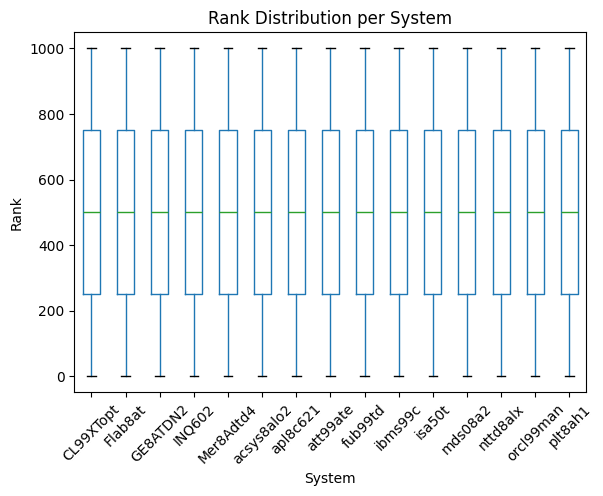

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df_runs.boxplot(column='rank', by='system_name', grid=False)
plt.title('Rank Distribution per System')
plt.suptitle('')
plt.xlabel('System')
plt.ylabel('Rank')
plt.xticks(rotation=45)
plt.show()

## 3.2 Merge System Runs With Qrels (Preprocessing)
* using shared keys: topic_id and doc_id
* ranking order from system runs + relevance labels from qrels

### Qrels
* If a document is NOT in qrels → relevance = 0
* Only some rows are judged others are assumed non-relevant (human limitation)
* 401 0 FBIS3-19107 1 means Document FBIS3-19107 is relevant to Topic 401, regardless of which system
* 401 0 LA052589-0094 0 means Document LA052589-0094 is NOT relevant to Topic 401, regardless of which system

In [ ]:
# Mark each doc as relevant/non-relevant (using qrels)
df_merged = df_runs.merge(
    df_qrels[['topic_id', 'doc_id', 'is_relevant']],
    on=['topic_id', 'doc_id'],
    how='left'
)

# If a retrieved document is not found in qrels, treat it as non-relevant
df_merged['is_relevant'] = df_merged['is_relevant'].fillna(0).astype(int)

# Sort properly by system, topic, and rank
df_merged = df_merged.sort_values(
    by=['system_name', 'topic_id', 'rank']
).reset_index(drop=True)

print(df_merged.head(50))

    topic_id Iteration         doc_id  rank     score system_name  is_relevant
0        401        Q0    FT932-10861     1  0.466239   CL99XTopt            0
1        401        Q0    FBIS3-30642     2  0.432951   CL99XTopt            0
2        401        Q0    FBIS3-40017     3  0.429149   CL99XTopt            0
3        401        Q0    FBIS4-18182     4  0.425154   CL99XTopt            0
4        401        Q0    FT934-15047     5  0.424532   CL99XTopt            0
5        401        Q0     FBIS3-5584     6  0.423666   CL99XTopt            0
6        401        Q0    FBIS3-38677     7  0.423611   CL99XTopt            0
7        401        Q0    FBIS4-23811     8  0.423541   CL99XTopt            0
8        401        Q0    FT931-16878     9  0.423072   CL99XTopt            0
9        401        Q0     FT924-7265    10  0.422821   CL99XTopt            0
10       401        Q0    FT932-13416    11  0.422771   CL99XTopt            0
11       401        Q0    FBIS3-18684    12  0.42219

## 3.3 Calculate MAP For Every System (MAP@1000)

* AP of 1 query = mean(precision at relevant ranks)


In [ ]:
# Step 1: Cumulative relevant documents
df_merged['cum_relevant'] = df_merged.groupby(
    ['system_name', 'topic_id']
)['is_relevant'].cumsum()

In [ ]:
# Step 2: All P@k
df_merged['precision_at_k'] = df_merged['cum_relevant'] / df_merged['rank']

print(df_merged[['system_name','topic_id','rank','is_relevant','cum_relevant','precision_at_k']].head(50))

   system_name  topic_id  rank  is_relevant  cum_relevant  precision_at_k
0    CL99XTopt       401     1            0             0        0.000000
1    CL99XTopt       401     2            0             0        0.000000
2    CL99XTopt       401     3            0             0        0.000000
3    CL99XTopt       401     4            0             0        0.000000
4    CL99XTopt       401     5            0             0        0.000000
5    CL99XTopt       401     6            0             0        0.000000
6    CL99XTopt       401     7            0             0        0.000000
7    CL99XTopt       401     8            0             0        0.000000
8    CL99XTopt       401     9            0             0        0.000000
9    CL99XTopt       401    10            0             0        0.000000
10   CL99XTopt       401    11            0             0        0.000000
11   CL99XTopt       401    12            0             0        0.000000
12   CL99XTopt       401    13        

In [ ]:
# Step 3: Filter only relevant rows
df_relevant = df_merged[df_merged['is_relevant'] == 1]

print(df_relevant[['system_name','topic_id','rank','precision_at_k']].head(50))

     system_name  topic_id  rank  precision_at_k
46     CL99XTopt       401    47        0.021277
54     CL99XTopt       401    55        0.036364
73     CL99XTopt       401    74        0.040541
91     CL99XTopt       401    92        0.043478
144    CL99XTopt       401   145        0.034483
145    CL99XTopt       401   146        0.041096
162    CL99XTopt       401   163        0.042945
165    CL99XTopt       401   166        0.048193
229    CL99XTopt       401   230        0.039130
237    CL99XTopt       401   238        0.042017
267    CL99XTopt       401   268        0.041045
275    CL99XTopt       401   276        0.043478
293    CL99XTopt       401   294        0.044218
297    CL99XTopt       401   298        0.046980
322    CL99XTopt       401   323        0.046440
339    CL99XTopt       401   340        0.047059
340    CL99XTopt       401   341        0.049853
354    CL99XTopt       401   355        0.050704
360    CL99XTopt       401   361        0.052632
365    CL99XTopt    

In [ ]:
# Step 4: AP
ap_df = df_relevant.groupby(
    ['system_name','topic_id']
)['precision_at_k'].mean().reset_index(name='AP')

print(ap_df.head(51))

   system_name  topic_id        AP
0    CL99XTopt       401  0.045943
1    CL99XTopt       402  0.246228
2    CL99XTopt       403  0.912352
3    CL99XTopt       404  0.263370
4    CL99XTopt       405  0.332472
5    CL99XTopt       406  0.339064
6    CL99XTopt       407  0.425842
7    CL99XTopt       408  0.342867
8    CL99XTopt       409  0.210810
9    CL99XTopt       410  0.810344
10   CL99XTopt       411  0.387386
11   CL99XTopt       412  0.181157
12   CL99XTopt       413  0.491835
13   CL99XTopt       414  0.210842
14   CL99XTopt       415  0.617670
15   CL99XTopt       416  0.332623
16   CL99XTopt       417  0.013758
17   CL99XTopt       418  0.350940
18   CL99XTopt       419  0.162499
19   CL99XTopt       420  0.462964
20   CL99XTopt       421  0.125601
21   CL99XTopt       422  0.627267
22   CL99XTopt       423  0.593364
23   CL99XTopt       424  0.301275
24   CL99XTopt       425  0.519586
25   CL99XTopt       426  0.098707
26   CL99XTopt       427  0.329183
27   CL99XTopt      

In [ ]:
# Step 5: MAP
map_df = ap_df.groupby('system_name')['AP'].mean().reset_index(name='MAP')

print(map_df)

   system_name       MAP
0    CL99XTopt  0.315375
1      Flab8at  0.353501
2     GE8ATDN2  0.337819
3       INQ602  0.316441
4    Mer8Adtd4  0.348696
5   acsys8alo2  0.324220
6     apl8c621  0.355732
7     att99ate  0.455821
8      fub99td  0.334420
9      ibms99c  0.385580
10      isa50t  0.305396
11     mds08a2  0.520620
12    nttd8alx  0.291644
13   orcl99man  0.341160
14     plt8ah1  0.376329


## 3.4 Calculate MAP@k For Every System (MAP@5, MAP@10, MAP@20, MAP@50, MAP@100, MAP@1000)

* Detailed calculation

In [ ]:
# Function to calculate AP@k matrix
def calculate_ap_at_k(df, k):
    print(f"\n========== Calculating AP@{k} ==========")

    # Keep only top k documents
    df_k = df[df['rank'] <= k].copy()

    print(f"\nStep 1: Top {k} documents only")
    print(df_k[['system_name', 'topic_id', 'rank', 'is_relevant']].head(k))

    # Cumulative relevant documents
    df_k['cum_relevant'] = df_k.groupby(
        ['system_name', 'topic_id']
    )['is_relevant'].cumsum()

    print("\nStep 2: Cumulative relevant")
    print(df_k[['system_name', 'topic_id', 'rank', 'is_relevant', 'cum_relevant']].head(k))

    # Precision at each rank
    df_k['precision_at_k'] = df_k['cum_relevant'] / df_k['rank']

    print("\nStep 3: Precision at each rank")
    print(df_k[['system_name', 'topic_id', 'rank', 'is_relevant', 'cum_relevant', 'precision_at_k']].head(k))

    # Keep only relevant documents
    df_relevant_k = df_k[df_k['is_relevant'] == 1].copy()

    print("\nStep 4: Relevant documents only")
    print(df_relevant_k[['system_name', 'topic_id', 'rank', 'precision_at_k']].head(k))

    # AP@k = average precision values where relevant documents are retrieved
    ap_k = df_relevant_k.groupby(
        ['topic_id', 'system_name']
    )['precision_at_k'].mean().reset_index(name=f'AP@{k}')

    print(f"\nStep 5: AP@{k} per topic per system")
    print(ap_k.head(20))

    # Convert into matrix: rows = topics, columns = systems
    ap_k_matrix = ap_k.pivot(
        index='topic_id',
        columns='system_name',
        values=f'AP@{k}'
    )

    print(f"\nAP@{k} Matrix Preview:")
    print(ap_k_matrix.head())

    ############### MAP@k per system
    mean_ap_k = ap_k_matrix.mean().sort_values(ascending=False)

    print(f"\nMAP@{k} per System:")
    print(mean_ap_k)

    return ap_k_matrix, mean_ap_k

In [ ]:
ap5_matrix, mean_ap5 = calculate_ap_at_k(df_merged, 5)
ap10_matrix, mean_ap10 = calculate_ap_at_k(df_merged, 10)
ap20_matrix, mean_ap20 = calculate_ap_at_k(df_merged, 20)
ap50_matrix, mean_ap50 = calculate_ap_at_k(df_merged, 50)
ap100_matrix, mean_ap100 = calculate_ap_at_k(df_merged, 100)
ap1000_matrix, mean_ap1000 = calculate_ap_at_k(df_merged, 1000)


========== Calculating AP@5 ==========

Step 1: Top 5 documents only
  system_name  topic_id  rank  is_relevant
0   CL99XTopt       401     1            0
1   CL99XTopt       401     2            0
2   CL99XTopt       401     3            0
3   CL99XTopt       401     4            0
4   CL99XTopt       401     5            0

Step 2: Cumulative relevant
  system_name  topic_id  rank  is_relevant  cum_relevant
0   CL99XTopt       401     1            0             0
1   CL99XTopt       401     2            0             0
2   CL99XTopt       401     3            0             0
3   CL99XTopt       401     4            0             0
4   CL99XTopt       401     5            0             0

Step 3: Precision at each rank
  system_name  topic_id  rank  is_relevant  cum_relevant  precision_at_k
0   CL99XTopt       401     1            0             0             0.0
1   CL99XTopt       401     2            0             0             0.0
2   CL99XTopt       401     3            0        

* Summary

In [ ]:
mean_ap_df = pd.DataFrame({
    'MAP@5': mean_ap5,
    'MAP@10': mean_ap10,
    'MAP@20': mean_ap20,
    'MAP@50': mean_ap50,
    'MAP@100': mean_ap100,
    'MAP@1000': mean_ap1000
})

print("\n===== MAP@k Summary =====")
print(mean_ap_df)

mean_ap_df.to_csv("MAP@k_per_System.csv")


===== MAP@k Summary =====
                MAP@5    MAP@10    MAP@20    MAP@50   MAP@100  MAP@1000
system_name                                                            
CL99XTopt    0.800711  0.696029  0.632664  0.527622  0.463852  0.315375
Flab8at      0.803924  0.692252  0.630662  0.541121  0.477212  0.353501
GE8ATDN2     0.782670  0.706720  0.647739  0.555305  0.484086  0.337819
INQ602       0.823747  0.704605  0.621737  0.547544  0.479531  0.316441
Mer8Adtd4    0.758274  0.693485  0.617184  0.535090  0.472251  0.348696
acsys8alo2   0.756741  0.690013  0.575257  0.482756  0.425477  0.324220
apl8c621     0.838855  0.749779  0.636943  0.551510  0.474187  0.355732
att99ate     0.866667  0.842318  0.801433  0.682113  0.602337  0.455821
fub99td      0.776422  0.699596  0.575867  0.502965  0.455366  0.334420
ibms99c      0.874155  0.845372  0.752233  0.647717  0.562696  0.385580
isa50t       0.791142  0.694954  0.613809  0.524432  0.471727  0.305396
mds08a2      0.901620  0.859728  0.80